# **Advanced Machine Learning Methods**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr. José Antonio Cantoral Ceballos**
### **Tecnológico de Monterrey**
## **Activity 3a: Exploring Word Embeddings with GloVe and Numpy**

---

### Team 7

- Rodrigo Robledo Castillo - A01797582
- Pedro David Juarez Leyva - A01797041
- Emilio Contreras Téllez - A01111353
- Omar Aguilar Macedo - A0179707

# Table of Contents
1. [Activity 3a: Exploring Word Embeddings with GloVe and Numpy](#activity_3a)
1. [Introduction](#introduction)
1. [Load File](#load)
1. [Create dictionary with embeddings](#create_dictionary)
1. [Plot Embeddings](#plot)
1. [Analogies](#analogies)
1. [N Most Similar](#most_similar)
1. [Conclusion](#conclusion)


## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy  <a name="activity_3a" />

<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project:
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)



# Introduction <a name="introduction" />
Word embeddings are numerical representations of words that capture semantic relationships by mapping words into a continuous vector space. Instead of representing words as discrete symbols, embeddings allow similar words to appear close to each other in this space, enabling tasks such as similarity measurement, clustering, and analogy reasoning.

In this work, we use GloVe (Global Vectors for Word Representation) embeddings. GloVe is an unsupervised algorithm that learns word vectors from global word co-occurrence statistics in large text corpora. The resulting embeddings capture meaningful linguistic patterns, where semantic relationships between words correspond to consistent directions in the vector space.

Specifically, we use the GloVe 6B 50-dimensional embeddings, where each word is represented by a vector of 50 numerical values trained on a corpus of approximately six billion tokens. This dimensionality provides a compact representation while still preserving important semantic relationships, making it suitable for visualization and experimentation.



In [1]:
# @title Import libraries

import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

## Load file <a name="load" />

In [2]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Set path for GloVe data file and dimentions of the file

# GloVE with 200 dimentional vectors
# PATH = '/content/drive/MyDrive/TC5033_MaaM/semana_07/glove.6B.200d.txt'

# GloVe with 50 dimentional vectors
PATH = '/content/drive/MyDrive/TC5033_MaaM/semana_07/glove.6B.50d.txt'

In [4]:
# This function reads a file and shows the first n_lines
def head_file(path, n_lines = 10):
  # Open file in `path` as read only
  with open(path, 'r') as f:
    # loop n times to read n lines
    for n in range(n_lines):
      # read a single line
      line = f.readline()
      # just to be safe, break if we are EOF
      if not line:
        break
      # print the line, but removing whitespace characters
      # from start and end of the line
      print(line.strip())


In [5]:
# Show the first 10 lines of the GloVe dataset
lines_to_show = 10
head_file(PATH, lines_to_show)

the 0.418 0.24968 -0.41242 0.1217 0.34527 -0.044457 -0.49688 -0.17862 -0.00066023 -0.6566 0.27843 -0.14767 -0.55677 0.14658 -0.0095095 0.011658 0.10204 -0.12792 -0.8443 -0.12181 -0.016801 -0.33279 -0.1552 -0.23131 -0.19181 -1.8823 -0.76746 0.099051 -0.42125 -0.19526 4.0071 -0.18594 -0.52287 -0.31681 0.00059213 0.0074449 0.17778 -0.15897 0.012041 -0.054223 -0.29871 -0.15749 -0.34758 -0.045637 -0.44251 0.18785 0.0027849 -0.18411 -0.11514 -0.78581
, 0.013441 0.23682 -0.16899 0.40951 0.63812 0.47709 -0.42852 -0.55641 -0.364 -0.23938 0.13001 -0.063734 -0.39575 -0.48162 0.23291 0.090201 -0.13324 0.078639 -0.41634 -0.15428 0.10068 0.48891 0.31226 -0.1252 -0.037512 -1.5179 0.12612 -0.02442 -0.042961 -0.28351 3.5416 -0.11956 -0.014533 -0.1499 0.21864 -0.33412 -0.13872 0.31806 0.70358 0.44858 -0.080262 0.63003 0.32111 -0.46765 0.22786 0.36034 -0.37818 -0.56657 0.044691 0.30392
. 0.15164 0.30177 -0.16763 0.17684 0.31719 0.33973 -0.43478 -0.31086 -0.44999 -0.29486 0.16608 0.11963 -0.41328 -0.42353

## Create dictionary with embeddings <a name="create_dictionary" />


In [6]:
# Function to create an embeddings dictionary from GloVe dataset
def create_emb_dictionary(path):
  # Python dictionary to store embeedings
  embeddings_dict = {}
  # Open the file in `path` as read only
  with open(path, 'r') as f:
    # read line by line
    for line in f:
      # Split line by spaces
      values = line.split()
      # Word, the first value
      word = values[0]
      # Embedding representation for the word, the rest of the line
      vector = np.asarray(values[1:], "float32")
      # Map word to embedding
      embeddings_dict[word] = vector

  return embeddings_dict


In [7]:
# @title get embeddings dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [8]:
# @title infer dimentions from embeddings_dict

# Get the first value from embeddings dictionary to set the embeddings dimentions
# assumes the dictionary contains embeddings of the same size, which is our case
first_value = next(iter(embeddings_dict.values()))
emb_dim = len(first_value)
emb_dim

50

In [9]:
print(f'count of words on embeddings_dict: {len(embeddings_dict):,d}')

count of words on embeddings_dict: 400,000


In [10]:
#@title Serialize/Deserialize embeddings functions

# Although not strictly necessary for this practice
# saving the dictionary to a file and load it
# is generally faster than re-creating it from the dataset
# each time we need it.

# file path to store the emebddings as pickle
embeddings_path = f'embeddings_dict-{emb_dim}D.pkl';

# Utility function to save the emebddings into a file
def save_embeddings_dict(embeddings_dict, path):
  with open(path, 'wb') as f:
      pickle.dump(embeddings_dict, f)

# Utility function to load embeddings from a file
# In real uses cases is more efficient to load a binary file
# than going to the process of reading source data, parse and create
# embeddings dictionary
def load_embeddings_dict(path):
  with open(path, 'rb') as f:
      embeddings_dict = pickle.load(f)
      return embeddings_dict


In [11]:
#@title validate Serialize/Desearlize functions
import numpy.testing as npt

save_embeddings_dict(embeddings_dict, embeddings_path)
embeddings_dict_loaded = load_embeddings_dict(embeddings_path)

# Validate utility functions for searialize/deserealize works
try:
    npt.assert_equal(embeddings_dict, embeddings_dict_loaded)
    print("embeddings_dict and load_embeddings_dict are equal (exact).")
except AssertionError as e:
    print(f"AssertionError: {e}")


embeddings_dict and load_embeddings_dict are equal (exact).


In [12]:
# @title Show some embeddings

# itertools is more efficient that converting the dict to a list
import itertools

# This function works like head_file but prints the output as an array,
# and the dimention of the embedding
# where:
#  the first vaule is the word, the rest of the values is the
#  embedding representation
def head_embeddings_file(path, n_words = 5):
  with open(path, 'r') as f:
    for _ in range(n_words):
      line = f.readline()
      if not line:
        break
      print(line.split(), len(line.split()[1:]))


# Another head function to display n entries, but this
# from a python dictionary with embeddings { word: numpy_embedding }
def head_embeddings_dict(embeddings_dict, n_words = 5):
  for key, value in itertools.islice(embeddings_dict.items(), n_words):
    print(f"""{colors.format('Word:', colors.BLUE)} '{key}'
  {colors.format('Embedding', colors.BLUE)} {value.tolist()}
  {colors.format('Dimention:', colors.BLUE)} {len(value)}""")

# Utility class to print colored text in terminals that support ANSI escape codes
# (e.g., Google Colab, Jupyter notebooks, most Unix terminals).
# This is useful for highlighting results or sections when printing outputs.
class colors:
    # ANSI color codes (foreground colors)
    RED     = '91'
    GREEN   = '92'
    YELLOW  = '93'
    BLUE    = '94'
    MAGENTA = '95'
    CYAN    = '96'
    WHITE   = '97'
    RESET   = '\033[0m' # Resets the color/style
    # Styles
    BOLD = '1;'

    """
    Wrap a string with ANSI escape codes to display colored text.

    Parameters
    ----------
    text : str
        Text to be formatted.
    color_code : str
        ANSI color code defined in this class.
    bold : bool
        Whether to apply bold style.

    Returns
    -------
    str
        Formatted string ready to be printed.
    """
    @staticmethod
    def format(text, color_code, bold = True):
        style = colors.BOLD if bold else ''
        return f"\033[{style}{color_code}m{text}{colors.RESET}"



In [13]:
head_embeddings_file(PATH, 5)

['the', '0.418', '0.24968', '-0.41242', '0.1217', '0.34527', '-0.044457', '-0.49688', '-0.17862', '-0.00066023', '-0.6566', '0.27843', '-0.14767', '-0.55677', '0.14658', '-0.0095095', '0.011658', '0.10204', '-0.12792', '-0.8443', '-0.12181', '-0.016801', '-0.33279', '-0.1552', '-0.23131', '-0.19181', '-1.8823', '-0.76746', '0.099051', '-0.42125', '-0.19526', '4.0071', '-0.18594', '-0.52287', '-0.31681', '0.00059213', '0.0074449', '0.17778', '-0.15897', '0.012041', '-0.054223', '-0.29871', '-0.15749', '-0.34758', '-0.045637', '-0.44251', '0.18785', '0.0027849', '-0.18411', '-0.11514', '-0.78581'] 50
[',', '0.013441', '0.23682', '-0.16899', '0.40951', '0.63812', '0.47709', '-0.42852', '-0.55641', '-0.364', '-0.23938', '0.13001', '-0.063734', '-0.39575', '-0.48162', '0.23291', '0.090201', '-0.13324', '0.078639', '-0.41634', '-0.15428', '0.10068', '0.48891', '0.31226', '-0.1252', '-0.037512', '-1.5179', '0.12612', '-0.02442', '-0.042961', '-0.28351', '3.5416', '-0.11956', '-0.014533', '-0.

In [14]:
# Show first 2 embeddings from embeddings_dict
head_embeddings_dict(embeddings_dict, 2)

Word: 'the'
  Embedding [0.4180000126361847, 0.24967999756336212, -0.41242000460624695, 0.1216999962925911, 0.3452700078487396, -0.044456999748945236, -0.4968799948692322, -0.17861999571323395, -0.0006602299981750548, -0.6565999984741211, 0.2784300148487091, -0.14767000079154968, -0.5567700266838074, 0.14657999575138092, -0.009509500116109848, 0.011657999828457832, 0.10204000025987625, -0.127920001745224, -0.8442999720573425, -0.12180999666452408, -0.016800999641418457, -0.33278998732566833, -0.15520000457763672, -0.23130999505519867, -0.1918099969625473, -1.8823000192642212, -0.7674599885940552, 0.09905099868774414, -0.42124998569488525, -0.19526000320911407, 4.0071001052856445, -0.1859399974346161, -0.5228700041770935, -0.3168100118637085, 0.0005921300034970045, 0.007444899994879961, 0.17778000235557556, -0.15896999835968018, 0.012040999718010426, -0.05422300100326538, -0.2987099885940552, -0.15749000012874603, -0.3475799858570099, -0.04563700035214424, -0.4425100088119507, 0.1878499

In [15]:
# Show first 2 embeddings from embeddings_dict_loaded
head_embeddings_dict(embeddings_dict_loaded, 2)

Word: 'the'
  Embedding [0.4180000126361847, 0.24967999756336212, -0.41242000460624695, 0.1216999962925911, 0.3452700078487396, -0.044456999748945236, -0.4968799948692322, -0.17861999571323395, -0.0006602299981750548, -0.6565999984741211, 0.2784300148487091, -0.14767000079154968, -0.5567700266838074, 0.14657999575138092, -0.009509500116109848, 0.011657999828457832, 0.10204000025987625, -0.127920001745224, -0.8442999720573425, -0.12180999666452408, -0.016800999641418457, -0.33278998732566833, -0.15520000457763672, -0.23130999505519867, -0.1918099969625473, -1.8823000192642212, -0.7674599885940552, 0.09905099868774414, -0.42124998569488525, -0.19526000320911407, 4.0071001052856445, -0.1859399974346161, -0.5228700041770935, -0.3168100118637085, 0.0005921300034970045, 0.007444899994879961, 0.17778000235557556, -0.15896999835968018, 0.012040999718010426, -0.05422300100326538, -0.2987099885940552, -0.15749000012874603, -0.3475799858570099, -0.04563700035214424, -0.4425100088119507, 0.1878499

## Plot Some Embeddings <a name="plot" />

In [16]:
# Plot word embeddings in a 2D space using a dimensionality reduction method
# (e.g., PCA or t-SNE).
def plot_embeddings(words, embeddings_dict, emb_dim, reducer=PCA,
                    figsize=(20,10), **reducer_kwargs):

    # Build the embedding matrix for the selected words
    embeddings = np.array([embeddings_dict[w] for w in words])

    # Apply dimensionality reduction:
    # embedding_dimension -> 2D
    reducer_model = reducer(n_components=2, random_state=42, **reducer_kwargs)
    vectors_2d = reducer_model.fit_transform(embeddings)

    # Plot the points
    plt.figure(figsize=figsize)
    # column 0 → x-axis
    # column 1 → y-axis
    plt.scatter(vectors_2d[:,0], vectors_2d[:,1], c="red")

    # Add word labels
    for i, word in enumerate(words):
        plt.annotate(word, (vectors_2d[i,0], vectors_2d[i,1]))

    plt.show()

In [17]:
words= [
  # food
  'burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips',
  # places
  'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
  # beverages
  'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
  # fruits
  'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
  # institutions
  'school', 'work', 'university', 'highschool'
]


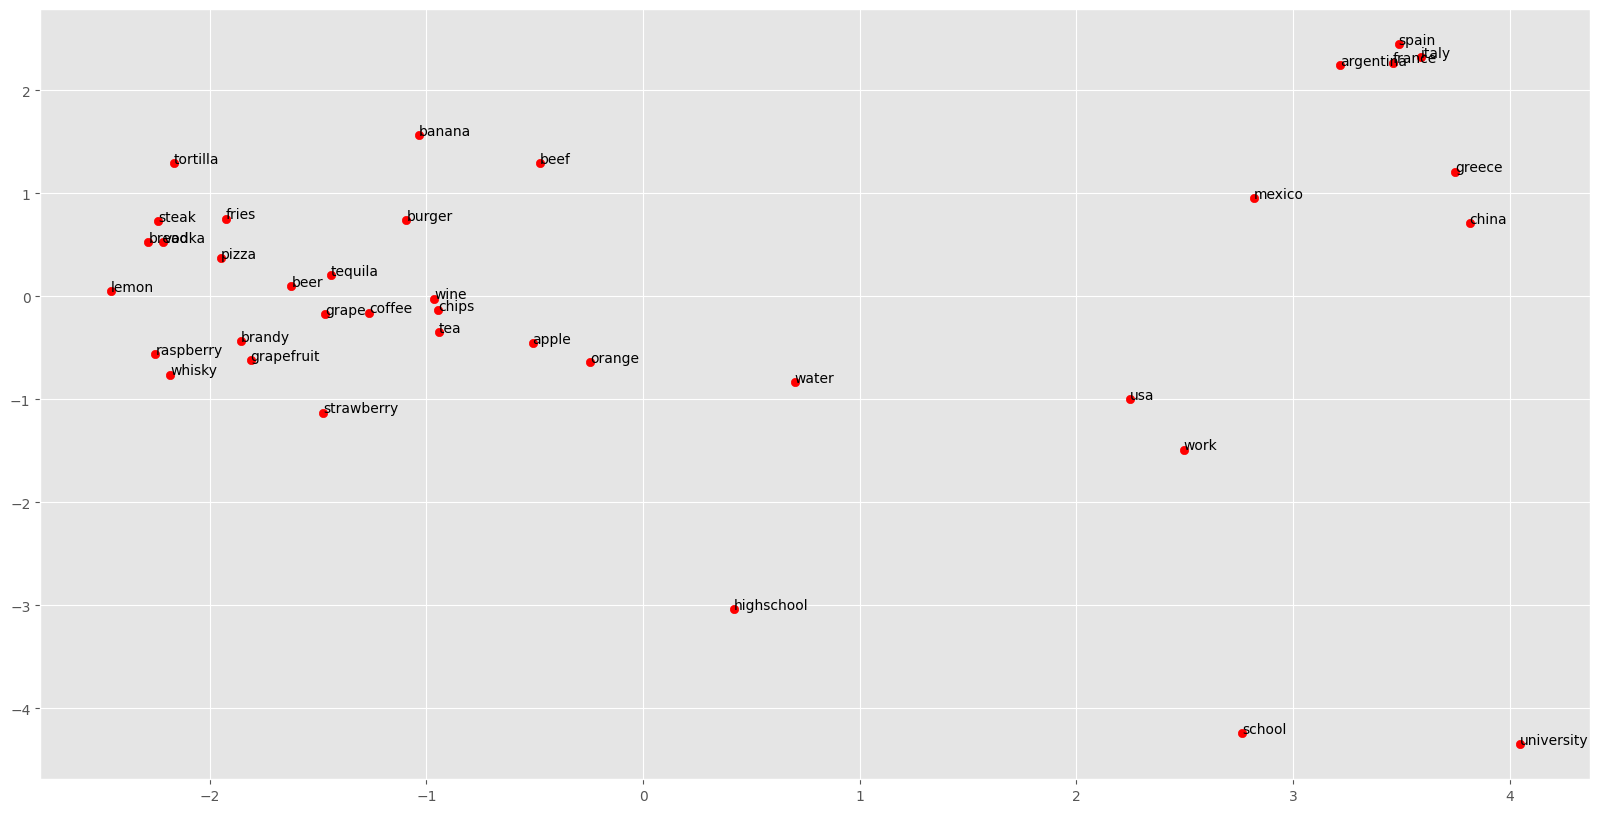

In [18]:
# PCA dimention reduction for visualization
plot_embeddings(words, embeddings_dict, emb_dim, reducer=PCA)

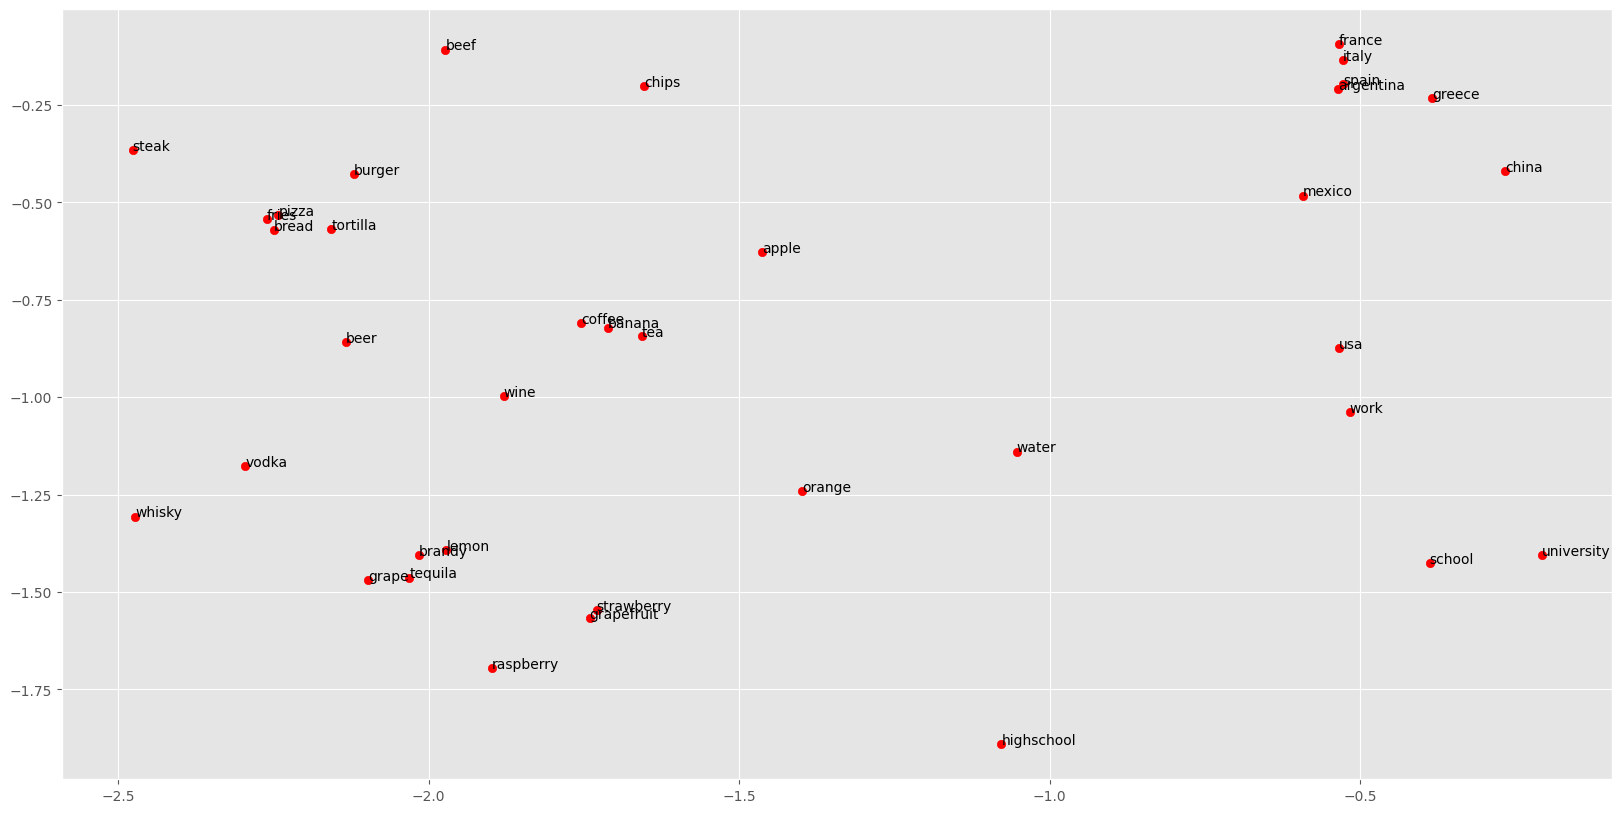

In [19]:
# t-SNE dimention reduction for visualization
plot_embeddings(words, embeddings_dict, emb_dim, reducer=TSNE)

In [20]:
# small set of words to see 2 different sets, that will be simpler to visualize
royalty_places = [
  # Royalty
  'man', 'woman', 'king', 'queen',
  # Places
  'paris', 'france', 'rome', 'italy'
]

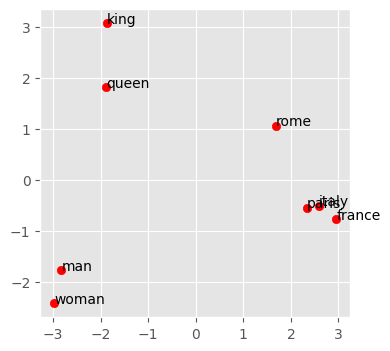

In [21]:
plot_embeddings(royalty_places, embeddings_dict, emb_dim, reducer=PCA, figsize=(4,4))

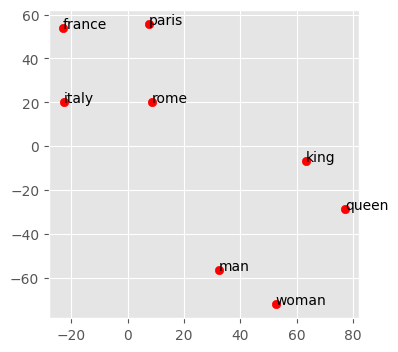

In [22]:
plot_embeddings(royalty_places, embeddings_dict, emb_dim, reducer=TSNE,
                figsize=(4,4), perplexity= 4)

## Analogies <a name="analogies" />

In [23]:
# analogy

# Compute cosine similarity between two vectors.
# Cosine similarity measures how aligned two vectors are in space,
# ignoring their magnitude. It is widely used with word embeddings
# to measure semantic similarity between words.
def cosine_similarity(v1, v2):
    # dot product / (norm_v1 * norm_v2)
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Compute the vector representing a word analogy.
# The classical embedding analogy operation is:
#    word1 : word2 :: word3 : ?
# which translates to the vector equation:
#    embedding(word2) - embedding(word1) + embedding(word3)
# Example:
# king - man + woman ≈ queen
def get_analogy_vector(word1, word2, word3, embeddings_dict):
  emb1, emb2, emb3 = embeddings_dict[word1], embeddings_dict[word2], embeddings_dict[word3]
  return emb2 - emb1 + emb3;

# Find the word that best completes an analogy using cosine similarity.
# This implementation performs a brute-force search over the entire
# vocabulary by computing similarity between the query vector and
# every embedding in the dictionary.
def analogy(word1, word2, word3, embeddings_dict):
  # Normalize input words to match dictionary format
  word1, word2, word3 = word1.lower(), word2.lower(), word3.lower()
  # Compute the analogy query vector
  query_vector = get_analogy_vector(word1, word2, word3, embeddings_dict)

  best_word = None
  best_score = -np.inf
  scores = []

  # Iterate through the vocabulary and compute similarity
  for word, emb in embeddings_dict.items():
    # Skip original words used in the analogy
    if word in [word1, word2, word3]:
      continue
    sim = cosine_similarity(query_vector, emb)

    # Keep track of the best match
    if sim > best_score:
      best_score = sim
      best_word = word
    scores.append((word, sim))
  return best_word

# Helper function to print analogies in a readable format
def print_analogy(word1, word2, word3, best_word):
  print(f'{word1} is to {word2} as {word3} to {best_word}')


In [24]:
words = ['man', 'king', 'woman']
best_word = analogy(*words, embeddings_dict)
print_analogy(*words, best_word)

man is to king as woman to queen


In [25]:
words = ['mexico', 'mexican', 'spain']
best_word = analogy(*words, embeddings_dict)
print_analogy(*words, best_word)

mexico is to mexican as spain to spanish


## N Most Similar <a name="most_similar" />

In [26]:
# pre normalization step, done once to improve efficiency
# when searching for top n similar
def normalize_embeddings(embeddings_dict):
    # Extract vocabulary
    words = list(embeddings_dict.keys())
    # Build embedding matrix
    V = np.stack([embeddings_dict[w] for w in words])
    # Normalize each vector (L2 normalization)
    V_norm = V / np.linalg.norm(V, axis=1, keepdims=True)
    # Map index -> word
    idx2word = np.array(words)

    return V_norm, idx2word

In [27]:
# This normalization can be done only once and reuse
V_norm, idx2words = normalize_embeddings(embeddings_dict)

In [28]:
# Find the top-N most similar embeddings using vectorized NumPy operations.
# Instead of looping through the vocabulary, we compute cosine similarity
# with all embeddings at once using a matrix-vector multiplication.
def find_most_similar_np(query_vec, V_norm, idx2word, top_n=5,
                         exclude_first=True):
    # Normalize query vector
    query_vec = query_vec / np.linalg.norm(query_vec)
    # Compute cosine similarity with all embeddings
    similarities = V_norm @ query_vec

    # When searching for neighbors of a word, the first result will usually
    # be the same word itself. In that case we fetch one extra result and
    # discard the first.
    top_n_search = top_n + exclude_first
    # Partial sorting for efficiency
    top_idx = np.argpartition(similarities, -top_n_search)[-top_n_search:]
    # Sort selected indices by similarity
    top_idx = top_idx[np.argsort(similarities[top_idx])[::-1]][exclude_first:]

    return [(idx2word[i], similarities[i]) for i in top_idx]

# Convenience wrapper to search similar words directly from a word string.
def find_most_similar(word, embeddings_dict, top_n=10):
    # Retrieve the embedding vector for the given word
    query_vector = embeddings_dict[word]
    return find_most_similar_np(query_vector, V_norm, idx2words)

# Similar to find_most_similar, but accepts a precomputed query vector.
# This is useful when performing analogy searches where the query vector
# is generated from multiple words.
def find_most_similar_query(query_vector, embeddings_dict, top_n=10):
    return find_most_similar_np(query_vector, V_norm, idx2words,
                                exclude_first = False)

In [29]:
# Helper function to print the most similar results in a readable format
def print_most_similar(most_similar):
  for i, w in enumerate(most_similar, 1):
      print(f'{i} -> {w[0]}')

In [30]:
print_most_similar(
  find_most_similar('mexico', embeddings_dict)
)

1 -> mexican
2 -> venezuela
3 -> colombia
4 -> peru
5 -> chile


In [31]:
print_most_similar(
  find_most_similar('frog', embeddings_dict)
)

1 -> snake
2 -> ape
3 -> toad
4 -> monkey
5 -> spider


In [32]:
print_most_similar(
  find_most_similar('dog', embeddings_dict)
)

1 -> cat
2 -> dogs
3 -> horse
4 -> puppy
5 -> pet


In [33]:
# @title analogy with find_most_similar

# We can reuse the function to find most_similar words
# To achieve the same results as with `analogy` function
words = ['mexico', 'mexican', 'spain']
query_vector = get_analogy_vector(*words, embeddings_dict)
# get first result, first value to fetch the actual word
best_word = find_most_similar_query(query_vector, embeddings_dict, 1)[0][0]
print_analogy(*words, best_word)


mexico is to mexican as spain to spanish


# Conclusion <a name="conclusion" />

The activity demonstrate how semantic information is encoded within word embeddings such as GloVe. By representing words as vectors, it becomes possible to analyze relationships between words using mathematical operations and similarity metrics.

To visualize the structure of the embedding space, two dimensionality reduction techniques were used: PCA and t-SNE. PCA performs a linear projection that preserves the overall variance of the dataset, providing a representation of the global structure of the embeddings. In contrast, t-SNE focuses on preserving local neighborhood relationships, which often produces clearer visual clusters of semantically related words.

Similarity between embeddings was measured using cosine similarity, which compares the angle between vectors rather than their magnitude. This metric is particularly effective for word embeddings because semantic similarity is mainly encoded in the direction of the vectors.

To efficiently find the most similar words, an optimization strategy was implemented by pre-normalizing the embeddings and computing similarities using vectorized NumPy operations. This approach allows the similarity between a query vector and the entire vocabulary to be computed simultaneously using matrix multiplication, significantly improving performance compared to iterating through each word individually.

Finally, the analogy experiments illustrate one of the key properties of word embeddings: semantic relationships can be expressed through vector arithmetic. Operations such as $king - man + woman ≈ queen$ show how consistent relationships between words are encoded as directions in the embedding space. This methodology provides a practical way to evaluate whether embeddings capture meaningful linguistic patterns.